# 🏎️ F1 Strategy Predictor - LSTM Model
## Predizione Pit Stop e Compound con Deep Learning

---

### Obiettivo del Progetto
Questo notebook risponde alle seguenti domande:

1. **È possibile prevedere quando un pilota effettuerà un pit stop?**
   - Predizione binaria: pit nei prossimi 3 giri? (Sì/No)
   - Metrica target: AUC-ROC ≥ 0.90

2. **È possibile prevedere quale compound verrà montato al prossimo pit?**
   - Predizione multiclass: SOFT, MEDIUM, HARD, INTERMEDIATE, WET
   - Metrica target: Accuracy ≥ 0.75


### Approccio
Due modelli LSTM separati con Attention mechanism:
- **Modello PIT**: Classificazione binaria con focus su raw features + minimal engineering
- **Modello COMPOUND**: Classificazione multiclass con pure raw features


### Prerequisiti
- `f1_dataset_clean.pkl` (generato dal notebook DataAnalysis)

# 1. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os, sys
import json

pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [2]:
import joblib
import json
import os

os.makedirs('Model', exist_ok=True)
os.makedirs('Other', exist_ok=True)

In [3]:
# FastF1: libreria open-source per dati F1 (telemetria, tempi, meteo)
import importlib.util
if importlib.util.find_spec('fastf1') is None:
    !pip install fastf1 --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.0/123.0 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.0/138.0 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 79.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 4.0 MB/s eta 0:00:00


In [4]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, roc_auc_score,
                             precision_recall_curve, roc_curve)

In [5]:
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, Dense, Dropout, BatchNormalization,
                                     Bidirectional, Masking, MultiHeadAttention,
                                     LayerNormalization, Add)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponibile: {tf.config.list_physical_devices('GPU')}")

# Riproducibilità
tf.random.set_seed(42)
np.random.seed(42)

TensorFlow version: 2.19.0
GPU disponibile: []


# 2. Import Dataset

In [6]:
# Carica il dataset già pulito (da notebook DataAnalysis)
# Le seguenti operazioni sono già state effettuate:
#   - Conversione Timedelta -> secondi (*Sec)
#   - Unificazione nomi team
#   - Rimozione compound non validi

df_f1 = pd.read_pickle('f1_dataset_clean.pkl')

print(f"Dataset caricato: {len(df_f1):,} righe")
print(f"\nTeam: {list(df_f1['Team'].unique())}")
print(f"\nCompound: {list(df_f1['Compound'].unique())}")

Dataset caricato: 86,757 righe

Team: ['Ferrari', 'Red Bull Racing', 'Mercedes', 'Haas F1 Team', 'Racing Bulls', 'Alpine', 'Williams', 'Kick Sauber', 'Aston Martin', 'McLaren']

Compound: ['SOFT', 'MEDIUM', 'HARD', 'INTERMEDIATE', 'WET']


# 3. Feature Engineering

---
## Targets

In [7]:
# Ordinamento cronologico: essenziale per sequenze temporali!
df_f1 = df_f1.sort_values(['Year', 'Round', 'Driver', 'LapNumber']).reset_index(drop=True)

**TARGET 1: PitIn3Laps** (Binary)
- 1 se pit entro i prossimi 3 giri, 0 altrimenti
- *Perché 3 giri?* Una finestra più ampia cattura l'imminenza del pit senza essere troppo generica. Un pit "imminente" a 1 giro è troppo restrittivo (poche sample positive).

In [8]:
# --- TARGET 1: PitIn3Laps ---

# Identifica i giri in cui il pilota pittarà entro i prossimi 3
df_f1['NextLapStint'] = df_f1.groupby(['Year', 'Round', 'Driver'])['Stint'].shift(-1)
# Lo shift -1 consente di spostare la colonna Stint verso l'alto = giro seguente
df_f1['IsPitLap'] = (df_f1['NextLapStint'] != df_f1['Stint']).astype(float).fillna(0)
# Fillna(0) sostituisce valori mancanti con 0. IsPtLap avrà valore 0/1.

# Aggregazione su finestra di 3 giri
df_f1['PitIn1'] = df_f1.groupby(['Year', 'Round', 'Driver'])['IsPitLap'].shift(-1).fillna(0)
# Lo shift -1 consente di spostare la colonna Stint verso l'alto = giro seguente
# Fillna(0) sostituisce valori NaN con 0 (ex. se considero ultimo giro)
df_f1['PitIn2'] = df_f1.groupby(['Year', 'Round', 'Driver'])['IsPitLap'].shift(-2).fillna(0)
df_f1['PitIn3'] = df_f1.groupby(['Year', 'Round', 'Driver'])['IsPitLap'].shift(-3).fillna(0)

df_f1['PitIn3Laps'] = ((df_f1['IsPitLap'] + df_f1['PitIn1'] + df_f1['PitIn2']
                        + df_f1['PitIn3']) > 0).astype(int)

In [9]:
# Pulizia colonne temporanee
df_f1 = df_f1.drop(columns=['PitIn1', 'PitIn2', 'PitIn3', 'NextLapStint'], errors='ignore')

print(f"Target PitIn3Laps: {df_f1['PitIn3Laps'].mean():.1%} positive")

Target PitIn3Laps: 20.7% positive


**TARGET 2: NextCompound** (Multiclass)
- Il compound che verrà montato al prossimo pit stop
- Classes: SOFT, MEDIUM, HARD, INTERMEDIATE, WET

In [10]:
# Per ogni giro, trova il compound del prossimo stint.
# Questo richiede di guardare avanti nella sequenza dei giri.

def get_next_compound(group):
    """
    Per ogni giro di un pilota, trova quale compound verrà montato al prossimo pit.
    Se il pilota non farà più pit, mantiene il compound attuale.
    """
    group = group.sort_values('LapNumber').copy()
    stints = group['Stint'].values
    compounds = group['StintCompound'].values
    result = compounds.copy()

    for i in range(len(group)):
        # Trova il prossimo stint diverso dall'attuale
        for j in range(i + 1, len(group)):
            if stints[j] != stints[i]:
                result[i] = compounds[j]
                break
    return result

In [11]:
# --- TARGET 2: NextCompound ---

# Prima creiamo il compound dello stint (primo compound usato nello stint)
df_f1['StintCompound'] = df_f1.groupby(['Year', 'Round', 'Driver', 'Stint'])['Compound'].transform('first')

# Applica la funzione per trovare il prossimo compound
next_compounds = []
for name, group in df_f1.groupby(['Year', 'Round', 'Driver']):
    next_compounds.extend(get_next_compound(group))

df_f1['NextCompound'] = next_compounds

In [12]:
# Pulizia colonne temporanee
df_f1 = df_f1.drop(columns=['StintCompound'], errors='ignore')

print(f"\nNextCompound distribution:")
print(df_f1['NextCompound'].value_counts())


NextCompound distribution:
NextCompound
HARD            45065
MEDIUM          24448
SOFT            13143
INTERMEDIATE     3971
WET               130
Name: count, dtype: int64


## Features Aggregate

### Filosofia: Minimal Engineering

Dopo test empirici, abbiamo scoperto che:
1. **Le raw features contengono già molta informazione** - l'LSTM può imparare pattern complessi
2. **Solo alcune engineered features aggiungono valore unico** - quelle che richiedono informazioni non presenti nei raw data

| Feature Engineered | Perché è Unica |
|-------------------|----------------|
| TyreMargin | Richiede domain knowledge (limiti compound-specifici) |
| LapTimeTrend3 | Segnale derivativo (tasso di cambiamento) |
| GapTrend | Segnale derivativo (tasso di cambiamento) |
| MyTyreVsField | Richiede dati degli ALTRI piloti |
| MyStintVsField | Richiede dati degli ALTRI piloti |

---
Per il Modello **PIT** (Quando pittare?)

| Categoria | Features | Tipo |
|-----------|----------|------|
| Temporali | LapNumber, Stint, StintProgress | RAW |
| Stato gomme | TyreLife, FreshTyre | RAW |
| Performance | LapTimeSec, Sector*TimeSec, Speed* | RAW |
| Condizioni | AirTemp, TrackTemp, Humidity, Pressure, WindSpeed | RAW |
| Safety | UnderSC, UnderVSC, UnderCaution | RAW |
| Gap | GapToLeader, Position | RAW |
| **Engineered** | TyreMargin, LapTimeTrend3, GapTrend, MyTyreVsField, MyStintVsField | **UNIQUE** |

In [13]:
FEATURES_PIT = [
    # --- RAW FEATURES (24) ---
    'LapNumber',
    'Stint',
    'Position',
    'TyreLife',
    'LapTimeSec',
    'Sector1TimeSec',
    'Sector2TimeSec',
    'Sector3TimeSec',
    'SpeedI1',
    'SpeedI2',
    'SpeedFL',
    'SpeedST',
    'AirTemp',
    'TrackTemp',
    'Humidity',
    'Pressure',
    'WindSpeed',
    'Rainfall',
    'UnderSC',
    'UnderVSC',
    'UnderCaution',
    'GapToLeader',
    'StintProgress',
    'FreshTyre',
    # --- ENGINEERED (5 unique) ---
    'TyreMargin',       # Domain knowledge: compound-specific limits
    'LapTimeTrend3',    # Derivative: performance rate of change
    'GapTrend',         # Derivative: gap rate of change
    'MyTyreVsField',    # Field comparison: requires other drivers' data
    'MyStintVsField'    # Field comparison: requires other drivers' data
]

print(f"Features PIT: {len(FEATURES_PIT)} (24 raw + 5 engineered)")

Features PIT: 29 (24 raw + 5 engineered)


---
Per il Modello **COMPOUND** (Quale gomma montare?)

**PURE RAW FEATURES** - I test hanno dimostrato che le raw features performano meglio delle engineered per questo task.

| Categoria | Features | Domanda |
|-----------|----------|----------|
| Compound attuale | IsSoft, IsMedium, IsHard, IsInter, IsWet | Cosa ho adesso? |
| Stato gara | LapNumber, Stint, Position, TyreLife | A che punto siamo? |
| Condizioni meteo | AirTemp, TrackTemp, Humidity, Pressure, WindSpeed, Rainfall | Serve gomma rain? |
| Safety | UnderSC, UnderVSC, UnderCaution | C'è safety car? |
| Stint | StintProgress, FreshTyre | Come sta la gomma? |

In [14]:
FEATURES_COMPOUND = [
    # --- PURE RAW FEATURES (20) ---
    'IsSoft',
    'IsMedium',
    'IsHard',
    'IsInter',
    'IsWet',
    'LapNumber',
    'Stint',
    'Position',
    'TyreLife',
    'AirTemp',
    'TrackTemp',
    'Humidity',
    'Pressure',
    'WindSpeed',
    'Rainfall',
    'UnderSC',
    'UnderVSC',
    'UnderCaution',
    'StintProgress',
    'FreshTyre'
]

print(f"Features COMPOUND: {len(FEATURES_COMPOUND)} (pure raw)")

Features COMPOUND: 20 (pure raw)


---
### 3.1 Preparazione Raw Features

Convertiamo le colonne categoriche/booleane nel formato corretto.

In [15]:
# One-hot encode Compound (necessario per COMPOUND model)
df_f1['IsSoft'] = (df_f1['Compound'] == 'SOFT').astype(int)
df_f1['IsMedium'] = (df_f1['Compound'] == 'MEDIUM').astype(int)
df_f1['IsHard'] = (df_f1['Compound'] == 'HARD').astype(int)
df_f1['IsInter'] = (df_f1['Compound'] == 'INTERMEDIATE').astype(int)
df_f1['IsWet'] = (df_f1['Compound'] == 'WET').astype(int)

# Convert booleans to int
df_f1['FreshTyre'] = df_f1['FreshTyre'].astype(int) if 'FreshTyre' in df_f1.columns else 0
df_f1['Rainfall'] = df_f1['Rainfall'].astype(int) if 'Rainfall' in df_f1.columns else 0

# UnderCaution: combina SC e VSC
df_f1['UnderCaution'] = ((df_f1.get('UnderSC', 0) == 1) | (df_f1.get('UnderVSC', 0) == 1)).astype(int)

print("Raw features preparate")
print(df_f1[['IsSoft', 'IsMedium', 'IsHard', 'IsInter', 'IsWet']].sum())

Raw features preparate
IsSoft      10397
IsMedium    31907
IsHard      39678
IsInter      4468
IsWet         307
dtype: int64


---
### 3.2 Features Engineered (Solo 5 Uniche per PIT)

Queste features aggiungono informazione **non derivabile dai raw data**:
1. **TyreMargin** - Richiede domain knowledge sui limiti compound-specifici
2. **LapTimeTrend3** - Segnale derivativo (tasso di cambiamento)
3. **GapTrend** - Segnale derivativo (tasso di cambiamento)
4. **MyTyreVsField** - Richiede dati degli ALTRI piloti
5. **MyStintVsField** - Richiede dati degli ALTRI piloti

In [16]:
# === ENGINEERED FEATURE 1: TyreMargin ===
# Encodes domain knowledge about compound-specific tire limits
# Can't be derived from TyreLife alone without knowing compound characteristics

# Valori basati su dati Pirelli e analisi telemetrie storiche
TYPICAL_STINT = {'SOFT': 18, 'MEDIUM': 28, 'HARD': 38, 'INTERMEDIATE': 25, 'WET': 20}

# Giri dall'inizio dello stint
df_f1['LapsInStint'] = df_f1.groupby(['Year', 'Round', 'Driver', 'Stint']).cumcount() + 1

# Vita tipica per questo compound
df_f1['TypicalStint'] = df_f1['Compound'].map(TYPICAL_STINT).fillna(25)

# TyreMargin: quanto "vita" rimane rispetto al tipico
# Positivo = gomma fresca, Negativo = oltre il limite tipico
df_f1['TyreMargin'] = (df_f1['TypicalStint'] - df_f1['LapsInStint']) / df_f1['TypicalStint']
df_f1['TyreMargin'] = df_f1['TyreMargin'].clip(-1, 1)

print(f"TyreMargin: {df_f1['TyreMargin'].describe()}")

TyreMargin: count   86757.00
mean        0.58
std         0.31
min        -1.00
25%         0.39
50%         0.64
75%         0.82
max         0.97
Name: TyreMargin, dtype: float64


In [17]:
# === ENGINEERED FEATURE 2: LapTimeTrend3 ===
# Derivative of lap time - shows RATE of performance change
# Raw LapTimeSec doesn't capture the trend direction

driver_grp = df_f1.groupby(['Year', 'Round', 'Driver'])

# Media mobile tempi (per ridurre rumore)
df_f1['LapTimeMA3'] = driver_grp['LapTimeSec'].transform(lambda x: x.rolling(3, min_periods=1).mean())

# Trend: deviazione dalla media mobile
# Positivo = sto peggiorando, Negativo = sto migliorando
df_f1['LapTimeTrend3'] = (df_f1['LapTimeSec'] - df_f1['LapTimeMA3']) / df_f1['LapTimeMA3']
df_f1['LapTimeTrend3'] = df_f1['LapTimeTrend3'].fillna(0)

print(f"LapTimeTrend3: {df_f1['LapTimeTrend3'].describe()}")

LapTimeTrend3: count   86757.00
mean       -0.00
std         0.01
min        -0.27
25%        -0.00
50%        -0.00
75%         0.00
max         0.41
Name: LapTimeTrend3, dtype: float64


In [18]:
# === ENGINEERED FEATURE 3: GapTrend ===
# Derivative of gap to leader - shows if gaining or losing
# Raw GapToLeader is absolute, this shows the rate of change

# Gap trend: sto guadagnando o perdendo sul leader?
df_f1['GapToLeader'] = df_f1['GapToLeader'].fillna(0)

# Variazione gap rispetto al giro precedente
df_f1['GapDiff'] = driver_grp['GapToLeader'].transform(lambda x: x.diff().fillna(0))

# Media mobile della variazione (smoothing)
df_f1['GapTrend'] = driver_grp['GapDiff'].transform(lambda x: x.rolling(3, min_periods=1).mean())
df_f1['GapTrend'] = df_f1['GapTrend'].fillna(0)

print(f"GapTrend: {df_f1['GapTrend'].describe()}")

GapTrend: count   86757.00
mean        1.00
std         3.65
min       -48.28
25%         0.09
50%         0.97
75%         1.85
max        75.37
Name: GapTrend, dtype: float64


In [19]:
# === ENGINEERED FEATURE 4 & 5: MyTyreVsField, MyStintVsField ===
# Comparison with OTHER drivers' tire age and stint
# Cannot be derived from single driver's raw data - requires field context

lap_grp = df_f1.groupby(['Year', 'Round', 'LapNumber'])

# Media età gomme del campo in questo giro
df_f1['FieldAvgTyre'] = lap_grp['TyreLife'].transform('mean')
# Confronto: positivo = gomme più vecchie della media, negativo = più fresche
df_f1['MyTyreVsField'] = (df_f1['TyreLife'] - df_f1['FieldAvgTyre']) / (df_f1['FieldAvgTyre'] + 1)
df_f1['MyTyreVsField'] = df_f1['MyTyreVsField'].fillna(0)

# Media stint del campo in questo giro
df_f1['FieldAvgStint'] = lap_grp['Stint'].transform('mean')
# Confronto: positivo = più stint degli altri (strategia aggressiva)
df_f1['MyStintVsField'] = df_f1['Stint'] - df_f1['FieldAvgStint']
df_f1['MyStintVsField'] = df_f1['MyStintVsField'].fillna(0)

print(f"MyTyreVsField: {df_f1['MyTyreVsField'].describe()}")
print(f"\nMyStintVsField: {df_f1['MyStintVsField'].describe()}")

MyTyreVsField: count   86757.00
mean        0.00
std         0.38
min        -0.95
25%        -0.20
50%         0.00
75%         0.17
max         4.46
Name: MyTyreVsField, dtype: float64

MyStintVsField: count   86757.00
mean        0.00
std         0.42
min        -2.12
25%        -0.17
50%        -0.05
75%         0.13
max         3.11
Name: MyStintVsField, dtype: float64


---
# 4. Preparazione Dati per Training

### 4.1 Pulizia e Validazione

In [20]:
# Gestione valori infiniti (da divisioni nelle features calcolate)
df_f1 = df_f1.replace([np.inf, -np.inf], np.nan)

# Fill NaN nelle features con mediana
all_features = list(set(FEATURES_PIT + FEATURES_COMPOUND))
for f in all_features:
    if f in df_f1.columns:
        df_f1[f] = df_f1[f].fillna(df_f1[f].median())

In [21]:
# Filtraggio per training
df_clean = df_f1.dropna(subset=['PitIn3Laps', 'NextCompound'])  # Target validi

# Encoding target compound
label_encoder = LabelEncoder()
df_clean['NextCompoundEnc'] = label_encoder.fit_transform(df_clean['NextCompound'])
print(f"\nClassi: {list(label_encoder.classes_)}")


Classi: ['HARD', 'INTERMEDIATE', 'MEDIUM', 'SOFT', 'WET']


### 4.2 Creazione Sequenze per LSTM

*Perché sequenze di 10 giri?*
L'LSTM ha bisogno di contesto temporale per catturare i trend: 10 giri è un buon compromesso: abbastanza per vedere il degrado, non troppo per includere rumore. Stint più corti vengono paddati con valMedio (il Masking layer li ignorerà)

In [22]:
SEQUENCE_LENGTH = 10  # Giri di storia per la predizione

# Crea sequenze temporali per LSTM
def create_sequences(df, features, target_col, seq_len):
    """
    Crea sequenze temporali per LSTM.
    Input: (samples, timesteps, features) = (N, 10, 14)
    Per ogni giro, prende i 'seq_len' giri precedenti come input.
    """
    X = []  # Input = sequenza di giri
    y = []  # Output = target (PitIn3Laps o NextCompoundEnc)
    available = [f for f in features if f in df.columns] # Filtra features esistenti

    for (year, rnd, driver, stint), group in df.groupby(['Year', 'Round', 'Driver', 'Stint']):
        group = group.sort_values('LapNumber')
        if len(group) < 3:  # Skip stint troppo corti
            continue

        data = group[available].values.astype(np.float32)
        targets = group[target_col].values

        # Per ogni giro, prendi i 'seq_len' giri precedenti come input per creare la sequenza
        for i in range(1, len(group)):  # Inizia da 1 (serve almeno 1 giro di storia)
            start = max(0, i - seq_len)
            seq = data[start:i]

            # Padding se sequenza troppo corta (padding con zeri)
            if len(seq) < seq_len:
                pad = np.zeros((seq_len - len(seq), len(available)), dtype=np.float32)
                seq = np.vstack([pad, seq])

            X.append(seq)
            y.append(targets[i])

    return np.array(X), np.array(y), available

In [23]:
# Filtra features esistenti
FEATURES_PIT = [f for f in FEATURES_PIT if f in df_clean.columns]
FEATURES_COMPOUND = [f for f in FEATURES_COMPOUND if f in df_clean.columns]
print(f"Features PIT effettive: {len(FEATURES_PIT)}")
print(f"Features COMPOUND effettive: {len(FEATURES_COMPOUND)}")

print("\nCreazione sequenze PIT...")
X_pit, y_pit, feat_pit = create_sequences(df_clean, FEATURES_PIT, 'PitIn3Laps', SEQUENCE_LENGTH)
print(f"  Shape: {X_pit.shape}")
print(f"  Classe positiva: {y_pit.mean():.1%}") # ~80% dei giri NON sono seguiti da pit

print("\nCreazione sequenze COMPOUND...")
X_comp, y_comp, feat_comp = create_sequences(df_clean, FEATURES_COMPOUND, 'NextCompoundEnc', SEQUENCE_LENGTH)
print(f"  Shape: {X_comp.shape}")

Features PIT effettive: 29
Features COMPOUND effettive: 20

Creazione sequenze PIT...
  Shape: (82099, 10, 29)
  Classe positiva: 21.5%

Creazione sequenze COMPOUND...
  Shape: (82099, 10, 20)


### 4.3 Split Train/Validation/Test

**Split Strategy:**
- Train: 70% - per apprendimento
- Validation: 15% - per early stopping e tuning
- Test: 15% - per valutazione finale

**Nota:** Usiamo stratified split per mantenere le proporzioni delle classi.

In [24]:
# Split PIT (stratificato per mantenere proporzione pit/no-pit)
# Uso la stratificazione perché il target è sbilanciato:
# senza stratify il modello vedrebbe set con percentuali pit/no-pit diverse,
# falsando validazione e test e rendendo le metriche non confrontabili.
X_pit_temp, X_pit_test, y_pit_temp, y_pit_test = train_test_split(
    X_pit, y_pit, test_size=0.15, random_state=42, stratify=y_pit
)
X_pit_train, X_pit_val, y_pit_train, y_pit_val = train_test_split(
    X_pit_temp, y_pit_temp, test_size=0.176, random_state=42, stratify=y_pit_temp
)

# Split COMPOUND (stratificato per mantenere proporzione delle mescole)
# Necessario perché alcune mescole sono molto meno frequenti:
# la stratificazione evita che val/test manchino di classi rare.
X_comp_temp, X_comp_test, y_comp_temp, y_comp_test = train_test_split(
    X_comp, y_comp, test_size=0.15, random_state=42, stratify=y_comp
)
X_comp_train, X_comp_val, y_comp_train, y_comp_val = train_test_split(
    X_comp_temp, y_comp_temp, test_size=0.176, random_state=42, stratify=y_comp_temp
)

print("Split completato:")
print(f"  PIT   - Train: {len(X_pit_train):,} | Val: {len(X_pit_val):,} | Test: {len(X_pit_test):,}")
print(f"  COMP  - Train: {len(X_comp_train):,} | Val: {len(X_comp_val):,} | Test: {len(X_comp_test):,}")

Split completato:
  PIT   - Train: 57,502 | Val: 12,282 | Test: 12,315
  COMP  - Train: 57,502 | Val: 12,282 | Test: 12,315


### 4.4 Normalizzazione e Class Weights

**Normalizzazione**: RobustScaler usa mediana invece di media
- *Perché?* Più robusto agli outliers (pit lap, safety car, outlap)

**Class Weights**: Bilancia le classi sbilanciate
- *Perché?* ~80% dei giri NON sono seguiti da pit -> il modello tenderebbe a predire sempre "no pit"

In [25]:
# Normalizzazione PIT
scaler_pit = RobustScaler()
n_features_pit = X_pit_train.shape[2] #   Shape: (81979, 10, 16)

X_pit_train = scaler_pit.fit_transform(X_pit_train.reshape(-1, n_features_pit)).reshape(X_pit_train.shape)
# = Shape: (81979, 10, 16) -> (819790, 16) -> norm -> (81979, 10, 16)
X_pit_val = scaler_pit.transform(X_pit_val.reshape(-1, n_features_pit)).reshape(X_pit_val.shape)
X_pit_test = scaler_pit.transform(X_pit_test.reshape(-1, n_features_pit)).reshape(X_pit_test.shape)


# Normalizzazione COMPOUND
scaler_comp = RobustScaler()
n_features_comp = X_comp_train.shape[2]   # Shape: (81979, 10, 15)

X_comp_train = scaler_comp.fit_transform(X_comp_train.reshape(-1, n_features_comp)).reshape(X_comp_train.shape)
# = Shape: (81979, 10, 15) -> (819790, 15) -> norm -> (81979, 10, 15)
X_comp_val = scaler_comp.transform(X_comp_val.reshape(-1, n_features_comp)).reshape(X_comp_val.shape)
X_comp_test = scaler_comp.transform(X_comp_test.reshape(-1, n_features_comp)).reshape(X_comp_test.shape)

In [26]:
# Class weights: weight = n_samples / (n_classes * n_samples_per_class)
# Classe rara -> weight alto

pit_counts = np.bincount(y_pit_train.astype(int))
pit_weight = {
    0: 1.0, # Classe di riferimento
    1: pit_counts[0] / pit_counts[1] # Classe rara
}
print(f"\nPit class weights:")
print(f"  Classe 0 (No Pit): {pit_weight[0]:.2f}")
print(f"  Classe 1 (Pit):    {pit_weight[1]:.2f}")

comp_counts = np.bincount(y_comp_train)
n_samples = len(y_comp_train)
comp_weight = { # non esiste una classe di riferimento
    0: n_samples / (5 * comp_counts[0]),
    1: n_samples / (5 * comp_counts[1]),
    2: n_samples / (5 * comp_counts[2]),
    3: n_samples / (5 * comp_counts[3]),
    4: n_samples / (5 * comp_counts[4]),
}
print(f"\nCompound class weights:")
for i, cls in enumerate(label_encoder.classes_):
    print(f"  {cls:12s}: {comp_weight[i]:.2f} (n={comp_counts[i]:,})")


Pit class weights:
  Classe 0 (No Pit): 1.00
  Classe 1 (Pit):    3.64

Compound class weights:
  HARD        : 0.38 (n=30,000)
  INTERMEDIATE: 4.47 (n=2,575)
  MEDIUM      : 0.71 (n=16,196)
  SOFT        : 1.33 (n=8,645)
  WET         : 133.73 (n=86)


---
# 5. Modelli LSTM

### 5.1 Architettura Modello PIT

**Scelte architetturali:**

1. **Bidirectional LSTM**: Cattura pattern temporali in entrambe le direzioni
   - *Perché bidirezionale?* Il degrado può essere visibile sia guardando avanti che indietro nella sequenza

2. **Multi-Head Self-Attention**: Permette al modello di "pesare" quali giri sono più importanti
   - *Perché?* Un giro con degrado anomalo 5 giri fa potrebbe essere più predittivo del giro precedente

3. **Residual Connection**: Migliora il gradient flow
   - *Perché?* Permette ai gradienti di fluire direttamente, evitando vanishing gradient

4. **Masking**: Ignora i padding (zeri) nelle sequenze corte

In [27]:
def build_pit_model(seq_len, n_features):
    """
    Modello per predizione PitIn3Laps (binary classification)

    Input: (batch, seq_len, n_features) - sequenza di giri
    Output: (batch, 1) - probabilità di pit nei prossimi 3 giri
    """
    inputs = Input(shape=(seq_len, n_features), name='input')

    # Masking: ignora i timestep paddati (tutti zeri)
    x = Masking(mask_value=0.0)(inputs)

    # Bidirectional LSTM 1: cattura pattern temporali
    # return_sequences=True per passare a attention
    x = Bidirectional(LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.1))(x)
    x = LayerNormalization()(x)

    # Multi-Head Self-Attention: "quali giri sono importanti per questa predizione?"
    # num_heads=4, key_dim=32 sono hyperparameter trovati sperimentalmente
    attention = MultiHeadAttention(num_heads=4, key_dim=32, dropout=0.1)(x, x)
    x = Add()([x, attention])  # Residual connection
    x = LayerNormalization()(x)

    # Bidirectional LSTM 2: estrae rappresentazione finale
    x = Bidirectional(LSTM(32, dropout=0.2, recurrent_dropout=0.1))(x)

    # Dense layers con regularizzazione
    x = Dense(48, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = Dense(24, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = Dropout(0.2)(x)

    # Output: sigmoid per classificazione binaria
    output = Dense(1, activation='sigmoid', name='pit')(x)

    model = Model(inputs=inputs, outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='prec'),
            tf.keras.metrics.Recall(name='rec')
        ]
    )

    return model

model_pit = build_pit_model(SEQUENCE_LENGTH, len(feat_pit))
model_pit.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 10, 29)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 10, 29)    │          0 │ input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 10, 29)    │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 10)        │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 10, 128)   │     48,128 │ masking[0][0],    │
│ (Bidirectional)     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 10, 128)   │        256 │ bidirectional[0]… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 10, 128)   │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 10, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 128)   │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or          │ (None, 10)        │          0 │ any[0][0],        │
│ (LogicalOr)         │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 64)        │     41,216 │ layer_normalizat… │
│ (Bidirectional)     │                   │            │ logical_or[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 48)        │      3,120 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 48)        │        192 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 48)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 24)        │      1,176 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 24)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pit (Dense)         │ (None, 1)         │         25 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 160,417 (626.63 KB)

 Trainable params: 160,321 (626.25 KB)

 Non-trainable params: 96 (384.00 B)

### 5.2 Training Modello PIT

In [28]:
# Callbacks:
# - EarlyStopping: ferma se val_auc non migliora per 12 epoche
# - ReduceLROnPlateau: riduce learning rate se val_loss non migliora
callbacks_pit = [
    EarlyStopping(monitor='val_auc', patience=12, restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

print("Training PIT model...")
print("="*60)
history_pit = model_pit.fit(
    X_pit_train, y_pit_train,
    validation_data=(X_pit_val, y_pit_val),
    epochs=50,
    batch_size=128,
    callbacks=callbacks_pit,
    class_weight=pit_weight,
    verbose=1
)

Training PIT model...
Epoch 1/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 102s 138ms/step - accuracy: 0.5662 - auc: 0.6534 - loss: 1.1784 - prec: 0.2899 - rec: 0.7063 - val_accuracy: 0.6540 - val_auc: 0.7614 - val_loss: 0.6416 - val_prec: 0.3561 - val_rec: 0.7515 - learning_rate: 0.0010
Epoch 2/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 60s 133ms/step - accuracy: 0.6585 - auc: 0.7380 - loss: 1.0117 - prec: 0.3532 - rec: 0.7304 - val_accuracy: 0.7066 - val_auc: 0.7945 - val_loss: 0.6365 - val_prec: 0.4014 - val_rec: 0.7379 - learning_rate: 0.0010
Epoch 3/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 59s 132ms/step - accuracy: 0.6940 - auc: 0.7731 - loss: 0.9512 - prec: 0.3841 - rec: 0.7292 - val_accuracy: 0.6891 - val_auc: 0.8096 - val_loss: 0.6478 - val_prec: 0.3915 - val_rec: 0.8014 - learning_rate: 0.0010
Epoch 4/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 82s 132ms/step - accuracy: 0.7167 - auc: 0.7961 - loss: 0.9044 - prec: 0.4077 - rec: 0.7361 - val_accuracy: 0.7384 - val_auc: 0.8386 - val_loss: 0.5587 - val_prec: 0.4397 - val_r

### 5.3 Architettura Modello COMPOUND

**Architettura simile al PIT con output multiclass:**

1. **Stessa struttura BiLSTM + Attention** - cattura pattern temporali
2. **Output softmax** - per 5 classi mutualmente esclusive
3. **Pure raw features** - i test hanno mostrato che performano meglio degli engineered

In [29]:
def build_compound_model(seq_len, n_features, n_classes):
    """
    Modello per predizione NextCompound (multiclass classification)

    Input: (batch, seq_len, n_features) - sequenza di giri
    Output: (batch, n_classes) - probabilità per ogni compound
    """
    inputs = Input(shape=(seq_len, n_features), name='input')

    x = Masking(mask_value=0.0)(inputs)

    # BiLSTM + Attention (stessa struttura del PIT)
    x = Bidirectional(LSTM(64, return_sequences=True, dropout=0.2, recurrent_dropout=0.1))(x)
    x = LayerNormalization()(x)

    attention = MultiHeadAttention(num_heads=4, key_dim=32, dropout=0.1)(x, x)
    x = Add()([x, attention])
    x = LayerNormalization()(x)

    x = Bidirectional(LSTM(32, dropout=0.2, recurrent_dropout=0.1))(x)

    x = Dense(48, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = Dense(24, activation='relu', kernel_regularizer=l2(0.001))(x)
    x = Dropout(0.2)(x)

    # Output: softmax per classificazione multiclass
    output = Dense(n_classes, activation='softmax', name='compound')(x)

    model = Model(inputs=inputs, outputs=output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

n_classes = len(label_encoder.classes_)
model_comp = build_compound_model(SEQUENCE_LENGTH, len(feat_comp), n_classes)
model_comp.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 10, 20)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_1         │ (None, 10, 20)    │          0 │ input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_1 (Masking) │ (None, 10, 20)    │          0 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_1 (Any)         │ (None, 10)        │          0 │ not_equal_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 10, 128)   │     43,520 │ masking_1[0][0],  │
│ (Bidirectional)     │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 128)   │        256 │ bidirectional_2[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 10, 128)   │     66,048 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 10, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 10, 128)   │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ logical_or_1        │ (None, 10)        │          0 │ any_1[0][0],      │
│ (LogicalOr)         │                   │            │ any_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 64)        │     41,216 │ layer_normalizat… │
│ (Bidirectional)     │                   │            │ logical_or_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 48)        │      3,120 │ bidirectional_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 48)        │        192 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 48)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 24)        │      1,176 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 24)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ compound (Dense)    │ (None, 5)         │        125 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 155,909 (609.02 KB)

 Trainable params: 155,813 (608.64 KB)

 Non-trainable params: 96 (384.00 B)

### 5.4 Training Modello COMPOUND

In [30]:
callbacks_comp = [
    EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

print("\nTraining COMPOUND model...")
print("="*60)
history_comp = model_comp.fit(
    X_comp_train, y_comp_train,
    validation_data=(X_comp_val, y_comp_val),
    epochs=50,
    batch_size=128,
    callbacks=callbacks_comp,
    class_weight=comp_weight,
    verbose=1
)


Training COMPOUND model...
Epoch 1/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 81s 132ms/step - accuracy: 0.3320 - loss: 1.6239 - val_accuracy: 0.6412 - val_loss: 1.0877 - learning_rate: 0.0010
Epoch 2/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 80s 127ms/step - accuracy: 0.5262 - loss: 1.1592 - val_accuracy: 0.6032 - val_loss: 1.1460 - learning_rate: 0.0010
Epoch 3/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 57s 126ms/step - accuracy: 0.6013 - loss: 1.0326 - val_accuracy: 0.6056 - val_loss: 1.1598 - learning_rate: 0.0010
Epoch 4/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 58s 128ms/step - accuracy: 0.6371 - loss: 0.9461 - val_accuracy: 0.5225 - val_loss: 1.3123 - learning_rate: 0.0010
Epoch 5/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 58s 128ms/step - accuracy: 0.6545 - loss: 0.9442 - val_accuracy: 0.7391 - val_loss: 0.8488 - learning_rate: 0.0010
Epoch 6/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 56s 125ms/step - accuracy: 0.6743 - loss: 0.8705 - val_accuracy: 0.7095 - val_loss: 0.9741 - learning_rate: 0.0010
Epoch 7/50
450/450 ━━━━━━━━━━━━━━━━━━━━ 57

---
# 6. Valutazione

**Metriche PIT:**
- **AUC-ROC**: Metrica principale, misura la capacità di distinguere tra Pit e No Pit indipendentemente dalla soglia
- **F1 Score**: Bilancia Precision e Recall
- **Soglia ottimale**: Trovata massimizzando F1 sulla curva precision-recall

**Metriche COMPOUND:**
- **Accuracy**: Proporzione di predizioni corrette
- **F1 (weighted)**: Media pesata degli F1 per classe
- **Per-class accuracy**: Per identificare classi problematiche

In [31]:
# ------ MODELLO PIT ------
print("\n" + "-"*50)
print("MODELLO PIT (PitIn3Laps)")
print("-"*50)

# Predizioni
y_pit_pred_prob = model_pit.predict(X_pit_test, verbose=0).flatten()

# Trova soglia ottimale (massimizza F1)
prec, rec, thresh = precision_recall_curve(y_pit_test, y_pit_pred_prob)
f1_arr = 2 * prec * rec / (prec + rec + 1e-8)
best_idx = np.argmax(f1_arr)
opt_thresh = thresh[best_idx] if best_idx < len(thresh) else 0.5

y_pit_pred = (y_pit_pred_prob > opt_thresh).astype(int)

# Metriche
pit_auc = roc_auc_score(y_pit_test, y_pit_pred_prob)
pit_f1 = f1_score(y_pit_test, y_pit_pred)
pit_acc = accuracy_score(y_pit_test, y_pit_pred)

print(f"AUC-ROC:   {pit_auc:.3f}")
print(f"F1 Score:  {pit_f1:.3f}")
print(f"Accuracy:  {pit_acc:.3f}")
print(f"Precision: {prec[best_idx]:.3f}")
print(f"Recall:    {rec[best_idx]:.3f}")
print(f"Soglia:    {opt_thresh:.3f}")

cm_pit = confusion_matrix(y_pit_test, y_pit_pred)
print(f"\nConfusion Matrix:")
print(f"           Pred:0  Pred:1")
print(f"True:0     {cm_pit[0,0]:6d}  {cm_pit[0,1]:6d}")
print(f"True:1     {cm_pit[1,0]:6d}  {cm_pit[1,1]:6d}")


--------------------------------------------------
MODELLO PIT (PitIn3Laps)
--------------------------------------------------
AUC-ROC:   0.938
F1 Score:  0.749
Accuracy:  0.889
Precision: 0.731
Recall:    0.767
Soglia:    0.746

Confusion Matrix:
           Pred:0  Pred:1
True:0       8916     748
True:1        618    2033


In [32]:
# ------ MODELLO COMPOUND ------
print("\n" + "-"*50)
print("MODELLO COMPOUND (NextCompound)")
print("-"*50)

y_comp_pred_prob = model_comp.predict(X_comp_test, verbose=0)
y_comp_pred = y_comp_pred_prob.argmax(axis=1)

comp_acc = accuracy_score(y_comp_test, y_comp_pred)
comp_f1 = f1_score(y_comp_test, y_comp_pred, average='weighted')

print(f"Accuracy:  {comp_acc:.3f}")
print(f"F1 (weighted): {comp_f1:.3f}")

# Per-class accuracy
print("\nPer-class accuracy:")
for i, cls in enumerate(label_encoder.classes_):
    mask = y_comp_test == i
    if mask.sum() > 0:
        cls_acc = (y_comp_pred[mask] == i).mean()
        cls_pred_count = (y_comp_pred == i).sum()
        print(f"  {cls:12s}: {cls_acc:.3f} (n={mask.sum():,}, pred={cls_pred_count:,})")

print(f"\nConfusion Matrix:")
cm_comp = confusion_matrix(y_comp_test, y_comp_pred)
print(f"Classes: {list(label_encoder.classes_)}")
print(cm_comp)


--------------------------------------------------
MODELLO COMPOUND (NextCompound)
--------------------------------------------------
Accuracy:  0.836
F1 (weighted): 0.836

Per-class accuracy:
  HARD        : 0.897 (n=6,425, pred=6,598)
  INTERMEDIATE: 0.897 (n=551, pred=661)
  MEDIUM      : 0.736 (n=3,469, pred=3,016)
  SOFT        : 0.791 (n=1,852, pred=1,959)
  WET         : 1.000 (n=18, pred=81)

Confusion Matrix:
Classes: ['HARD', 'INTERMEDIATE', 'MEDIUM', 'SOFT', 'WET']
[[5763   65  317  269   11]
 [   0  494    4    7   46]
 [ 607   86 2552  218    6]
 [ 228   16  143 1465    0]
 [   0    0    0    0   18]]


### 6.1 Feature Importance

*Come funziona?* Per ogni feature, si permutano casualmente i suoi valori e si misura quanto peggiora la performance (estensione del concetto di permutation importance ai modelli neurali).

In [33]:
def permutation_importance(model, X, y, features, n_repeats=3, metric='auc'):
    """Calcola l'importanza delle features tramite permutation."""
    # Baseline performance
    y_pred = model.predict(X, verbose=0)
    if metric == 'auc':
        baseline = roc_auc_score(y, y_pred.flatten())
    else:
        baseline = accuracy_score(y, y_pred.argmax(axis=1))

    importances = {}
    for i, feat in enumerate(features):
        scores = []
        for _ in range(n_repeats):
            X_perm = X.copy()
            # Permuta la feature i su tutti i timestep
            perm_idx = np.random.permutation(len(X_perm))
            X_perm[:, :, i] = X_perm[perm_idx, :, i]

            y_pred_perm = model.predict(X_perm, verbose=0)
            if metric == 'auc':
                score = roc_auc_score(y, y_pred_perm.flatten())
            else:
                score = accuracy_score(y, y_pred_perm.argmax(axis=1))
            scores.append(score)

        importances[feat] = baseline - np.mean(scores)

    return dict(sorted(importances.items(), key=lambda x: x[1], reverse=True))

In [34]:
print("Calcolo feature importance PIT...")
pit_importance = permutation_importance(model_pit, X_pit_test, y_pit_test, feat_pit, metric='auc')

print("\nTop 10 features PIT:")
for feat, imp in list(pit_importance.items())[:10]:
    print(f"  {feat:20s}: {imp:.4f}")

Calcolo feature importance PIT...

Top 10 features PIT:
  Pressure            : 0.0659
  TyreMargin          : 0.0612
  SpeedST             : 0.0585
  MyTyreVsField       : 0.0561
  MyStintVsField      : 0.0550
  LapNumber           : 0.0518
  GapTrend            : 0.0459
  TyreLife            : 0.0412
  Stint               : 0.0400
  WindSpeed           : 0.0399


In [35]:
print("Calcolo feature importance COMPOUND...")
comp_importance = permutation_importance(model_comp, X_comp_test, y_comp_test, feat_comp, metric='accuracy')

print("\nTop 10 features COMPOUND:")
for feat, imp in list(comp_importance.items())[:10]:
    print(f"  {feat:20s}: {imp:.4f}")

Calcolo feature importance COMPOUND...

Top 10 features COMPOUND:
  LapNumber           : 0.1855
  Stint               : 0.1679
  IsMedium            : 0.1604
  IsSoft              : 0.0799
  WindSpeed           : 0.0771
  Humidity            : 0.0711
  IsHard              : 0.0653
  AirTemp             : 0.0551
  TrackTemp           : 0.0523
  Pressure            : 0.0456


### 6.2 Visualizzazione Training History

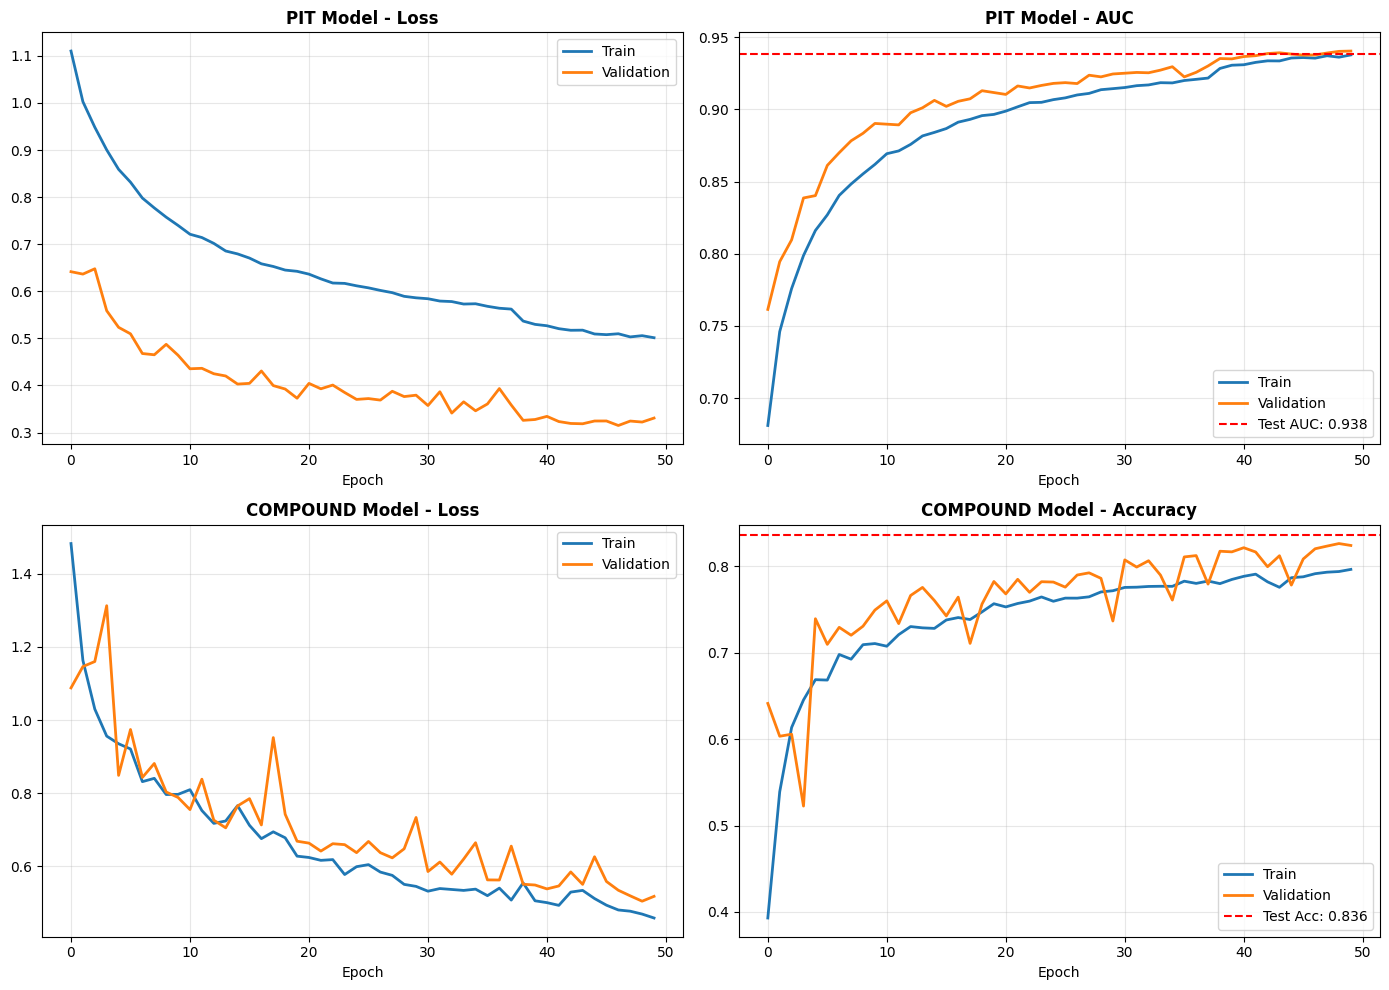

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# PIT - Loss
axes[0, 0].plot(history_pit.history['loss'], label='Train', linewidth=2)
axes[0, 0].plot(history_pit.history['val_loss'], label='Validation', linewidth=2)
axes[0, 0].set_title('PIT Model - Loss', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# PIT - AUC
axes[0, 1].plot(history_pit.history['auc'], label='Train', linewidth=2)
axes[0, 1].plot(history_pit.history['val_auc'], label='Validation', linewidth=2)
axes[0, 1].axhline(y=pit_auc, color='r', linestyle='--', label=f'Test AUC: {pit_auc:.3f}')
axes[0, 1].set_title('PIT Model - AUC', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# COMPOUND - Loss
axes[1, 0].plot(history_comp.history['loss'], label='Train', linewidth=2)
axes[1, 0].plot(history_comp.history['val_loss'], label='Validation', linewidth=2)
axes[1, 0].set_title('COMPOUND Model - Loss', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# COMPOUND - Accuracy
axes[1, 1].plot(history_comp.history['accuracy'], label='Train', linewidth=2)
axes[1, 1].plot(history_comp.history['val_accuracy'], label='Validation', linewidth=2)
axes[1, 1].axhline(y=comp_acc, color='r', linestyle='--', label=f'Test Acc: {comp_acc:.3f}')
axes[1, 1].set_title('COMPOUND Model - Accuracy', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('Other/training_history.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Visualizzazione Feature Importance

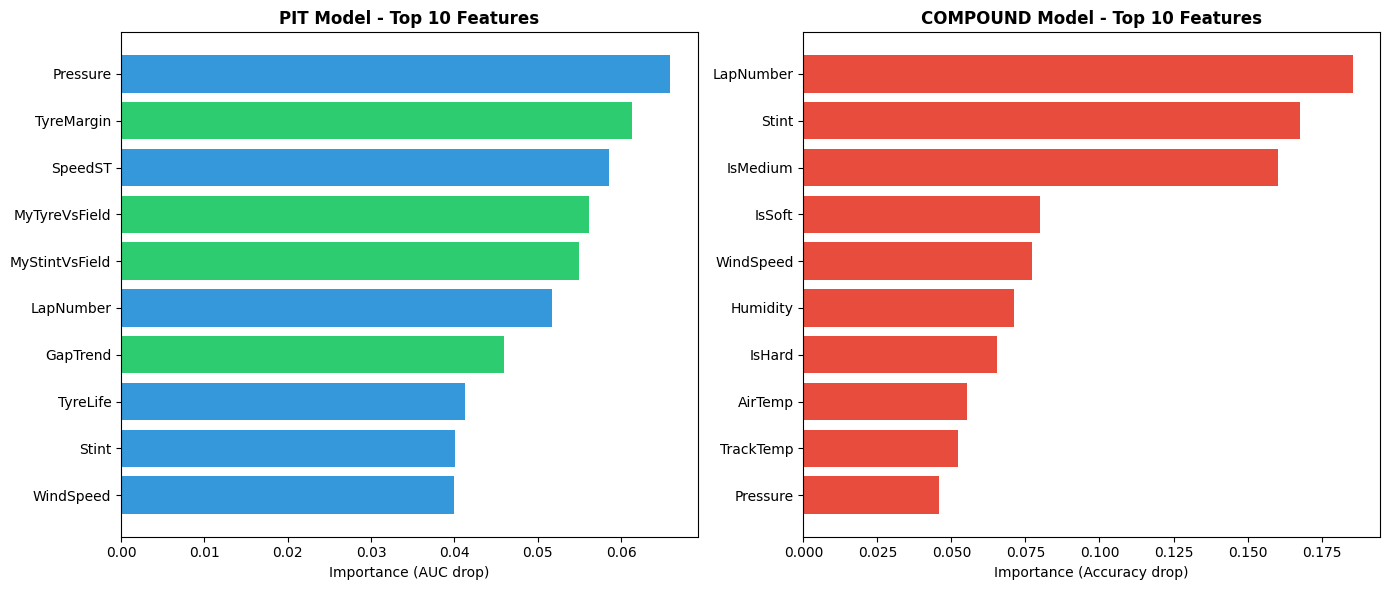


🟢 Green = Engineered features (unique information)
🔵 Blue = Raw features


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# PIT feature importance
pit_top10 = dict(list(pit_importance.items())[:10])
colors_pit = ['#2ecc71' if 'Vs' in f or 'Trend' in f or 'Margin' in f else '#3498db' for f in pit_top10.keys()]
axes[0].barh(list(pit_top10.keys())[::-1], list(pit_top10.values())[::-1], color=colors_pit[::-1])
axes[0].set_xlabel('Importance (AUC drop)')
axes[0].set_title('PIT Model - Top 10 Features', fontweight='bold')
axes[0].axvline(x=0, color='black', linewidth=0.5)

# COMPOUND feature importance
comp_top10 = dict(list(comp_importance.items())[:10])
axes[1].barh(list(comp_top10.keys())[::-1], list(comp_top10.values())[::-1], color='#e74c3c')
axes[1].set_xlabel('Importance (Accuracy drop)')
axes[1].set_title('COMPOUND Model - Top 10 Features', fontweight='bold')
axes[1].axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('Other/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🟢 Green = Engineered features (unique information)")
print("🔵 Blue = Raw features")

---
# 7. Save

In [38]:
# Salva modelli Keras
model_pit.save('Model/f1_pit_model.keras')
model_comp.save('Model/f1_compound_model.keras')
print("✓ Modelli salvati")

✓ Modelli salvati


In [39]:
# Salva scaler e encoder
joblib.dump(scaler_pit, 'Model/f1_pit_scaler.pkl')
joblib.dump(scaler_comp, 'Model/f1_comp_scaler.pkl')
joblib.dump(label_encoder, 'Model/label_encoder.pkl')
print("✓ Scaler e encoder salvati")

✓ Scaler e encoder salvati


In [40]:
# Salva configurazione
config = {
    'sequence_length': SEQUENCE_LENGTH,
    'features_pit': feat_pit,
    'features_pit_engineered': ['TyreMargin', 'LapTimeTrend3', 'GapTrend', 'MyTyreVsField', 'MyStintVsField'],
    'features_compound': feat_comp,
    'pit_threshold': float(opt_thresh),
    'compound_classes': list(label_encoder.classes_),
    'philosophy': 'minimal_engineering',
    'metrics': {
        'pit_auc': float(pit_auc),
        'pit_f1': float(pit_f1),
        'pit_accuracy': float(pit_acc),
        'compound_accuracy': float(comp_acc),
        'compound_f1': float(comp_f1)
    }
}

with open('Model/modelConfig.json', 'w') as f:
    json.dump(config, f, indent=2)
print("✓ Configurazione salvata")

✓ Configurazione salvata


In [41]:
# Salva il dataset completo con tutte le features
df_f1.to_pickle('Other/f1_dataset_features.pkl')
print("✓ Dataset con features salvato")

print("\n" + "="*60)
print("TRAINING COMPLETATO!")
print("="*60)
print(f"\nPIT Model:      AUC={pit_auc:.3f}, F1={pit_f1:.3f}")
print(f"COMPOUND Model: Accuracy={comp_acc:.3f}, F1={comp_f1:.3f}")

✓ Dataset con features salvato

TRAINING COMPLETATO!

PIT Model:      AUC=0.938, F1=0.749
COMPOUND Model: Accuracy=0.836, F1=0.836
